laboneq version: 26.7.0
LO = 7.200 GHz, IF sweep -50.0 -> 0.0 MHz
[2026.08.05 16:33:30.978] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\QNL\ZIScripts\laboneq_output\log
[2026.08.05 16:33:30.982] INFO    VERSION: laboneq 26.7.0
[2026.08.05 16:33:30.985] INFO    Connecting to data server at localhost:8004
[2026.08.05 16:33:30.991] INFO    Connected to Zurich Instruments LabOne Data Server version 26.07.1.4 at localhost:8004
[2026.08.05 16:33:31.005] INFO    Configuring the device setup


[2026.08.05 16:33:32.233] INFO    The device setup is configured
[2026.08.05 16:33:33.020] INFO    Starting LabOne Q Compiler run...
[2026.08.05 16:33:33.022] INFO    Schedule completed. [0.001 s]
[2026.08.05 16:33:33.031] INFO    Code generation completed. [0.008 s]
[2026.08.05 16:33:33.032] INFO    Completed compilation step 1 of 1. [0.011 s]
[2026.08.05 16:33:33.039] INFO     ────────────────────────────────────────────────────────────────── 
[2026.08.05 16:33:33.040] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.08.05 16:33:33.041] INFO     ────────────────────────────────────────────────────────────────── 
[2026.08.05 16:33:33.042] INFO      device_shfqc     0         21            0           1      8000  
[2026.08.05 16:33:33.042] INFO     ────────────────────────────────────────────────────────────────── 
[2026.08.05 16:33:33.043] INFO      TOTAL                      21            0                  8000  
[2026.08.05 16:33:33.044] INFO     

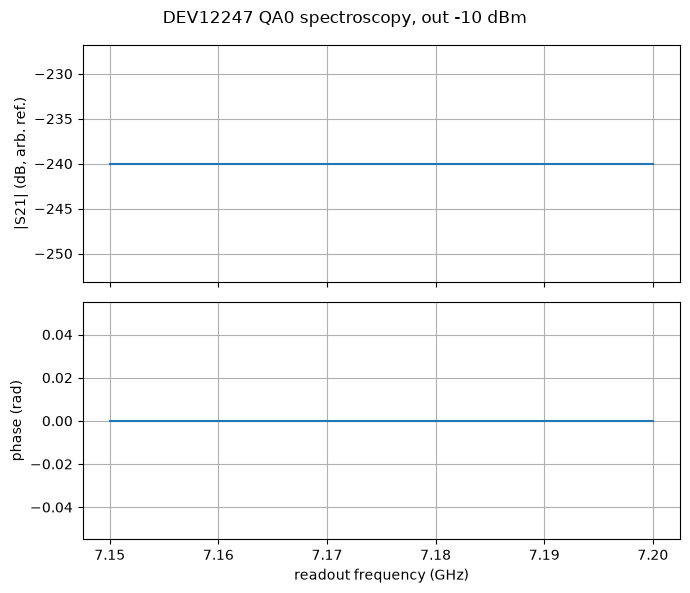

[2026.08.05 16:33:34.211] INFO    Disconnecting from all devices and servers...
[2026.08.05 16:33:34.212] INFO    Successfully disconnected from all devices and servers.


In [12]:
"""
Resonator (readout) spectroscopy in SHFQA "spectroscopy mode" on an SHFQC.

Device:      DEV12247 (SHFQC), QA channel 0
Sweep:       7.150 GHz -> 7.200 GHz
Output:      -10 dBm  (range = -10 dBm, pulse amplitude = 1.0 -> full scale)
Input:        0 dBm range

Run with EMULATE = True first to check the sequence compiles, then set False.
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

import laboneq
from laboneq.simple import *

# --------------------------------------------------------------------------
# 1. User settings
# --------------------------------------------------------------------------
DEVICE_ID   = "DEV12247"
SERVER_HOST = "localhost"      # host running the LabOne data server
SERVER_PORT = 8004
INTERFACE   = "1GbE"           # "1GbE" or "USB"
EMULATE     = False
RESET_DEVICE = True            # clean device state on connect (nice for debugging)

QA_CHANNEL  = 0                # SHFQC QA channel (there is only one: 0)

F_START     = 7.150e9
F_STOP      = 7.200e9
N_POINTS    = 201

# SHF center (LO) frequency must be a multiple of 100 MHz.
# With LO = 7.1 GHz the digital IF sweeps 50 MHz -> 100 MHz, comfortably
# inside the +/-350 MHz analysis band and away from the LO leakage at IF = 0.
LO_FREQ     = 7.2e9

OUTPUT_RANGE_DBM = -10         # allowed in 5 dB steps
INPUT_RANGE_DBM  = 0           # allowed in 5 dB steps

PULSE_LENGTH      = 2e-6       # readout tone length
INTEGRATION_TIME  = 2e-6       # spectroscopy-mode integration length
NUM_AVERAGES      = 2**10
RELAX_TIME        = 1e-6
ACQ_PORT_DELAY    = 0.0        # add cable/fridge round-trip delay here if needed

SAVE_NPZ = "shfqc_res_spec.npz"   # set to None to skip saving

# --------------------------------------------------------------------------
# 2. Sanity checks on the frequency plan
# --------------------------------------------------------------------------
if_start = F_START - LO_FREQ
if_stop  = F_STOP - LO_FREQ
assert abs(LO_FREQ % 200e6) < 1e-3, "SHF center frequency must be a multiple of 100 MHz"
assert max(abs(if_start), abs(if_stop)) <= 350e6, "IF outside the +/-350 MHz band"

print(f"laboneq version: {laboneq.__version__}")
print(f"LO = {LO_FREQ/1e9:.3f} GHz, IF sweep {if_start/1e6:.1f} -> {if_stop/1e6:.1f} MHz")

# --------------------------------------------------------------------------
# 3. Device setup
# --------------------------------------------------------------------------
descriptor = f"""
instruments:
  SHFQC:
    - address: {DEVICE_ID}
      uid: device_shfqc
      interface: {INTERFACE}
      options: SHFQC/PLUS/QC6CH
connections:
  device_shfqc:
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/{QA_CHANNEL}/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/{QA_CHANNEL}/INPUT]
"""

device_setup = DeviceSetup.from_descriptor(
    descriptor,
    server_host=SERVER_HOST,
    server_port=SERVER_PORT,
    setup_name="shfqc_standalone",
)

lsg = device_setup.logical_signal_groups["q0"].logical_signals

# Baseline calibration: LO, ranges, port delay
base_cal = Calibration()
base_cal[lsg["measure_line"]] = SignalCalibration(
    local_oscillator=Oscillator(uid="lo_qa", frequency=LO_FREQ),
    range=OUTPUT_RANGE_DBM,
)
base_cal[lsg["acquire_line"]] = SignalCalibration(
    local_oscillator=Oscillator(uid="lo_qa", frequency=LO_FREQ),
    range=INPUT_RANGE_DBM,
    port_delay=ACQ_PORT_DELAY,
)
device_setup.set_calibration(base_cal)

# --------------------------------------------------------------------------
# 4. Experiment
# --------------------------------------------------------------------------
if_sweep = SweepParameter(
    uid="if_freq",
    values=np.linspace(if_start, if_stop, N_POINTS),
)

readout_pulse = pulse_library.const(
    uid="readout_pulse",
    length=PULSE_LENGTH,
    amplitude=1.0,          # 1.0 => output power == output range == -10 dBm
)

exp = Experiment(
    uid="resonator_spectroscopy",
    signals=[
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)

with exp.acquire_loop_rt(
    uid="shots",
    count=NUM_AVERAGES,
    acquisition_type=AcquisitionType.SPECTROSCOPY,
    averaging_mode=AveragingMode.CYCLIC,
):
    with exp.sweep(uid="freq_sweep", parameter=if_sweep):
        with exp.section(uid="readout", alignment=SectionAlignment.LEFT):
            exp.play(signal="measure", pulse=readout_pulse)
            exp.acquire(signal="acquire", handle="res_spec", length=INTEGRATION_TIME)
        with exp.section(uid="relax"):
            exp.delay(signal="measure", time=RELAX_TIME)

# The swept digital oscillator lives on the QA channel and is shared by the
# output and the input path in spectroscopy mode -> set it on the measure line.
exp_cal = Calibration()
exp_cal["measure"] = SignalCalibration(
    oscillator=Oscillator(
        uid="qa_osc",
        frequency=if_sweep,
        modulation_type=ModulationType.HARDWARE,
    ),
)
exp.set_calibration(exp_cal)

exp.set_signal_map(
    {
        "measure": lsg["measure_line"],
        "acquire": lsg["acquire_line"],
    }
)

# --------------------------------------------------------------------------
# 5. Run
# --------------------------------------------------------------------------
session = Session(device_setup=device_setup)
session.connect(do_emulation=EMULATE, reset_devices=RESET_DEVICE)

compiled = session.compile(exp)
results = session.run(compiled)

data = np.asarray(results.get_data("res_spec"))
freqs = LO_FREQ + np.asarray(if_sweep.values)

amp = np.abs(data)
phase = np.unwrap(np.angle(data))

if SAVE_NPZ:
    np.savez(SAVE_NPZ, frequency=freqs, s21=data)
    print(f"saved {SAVE_NPZ}")

# --------------------------------------------------------------------------
# 6. Plot
# --------------------------------------------------------------------------
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6))
ax[0].plot(freqs / 1e9, 20 * np.log10(np.maximum(amp, 1e-12)))
ax[0].set_ylabel("|S21| (dB, arb. ref.)")
ax[0].grid(True)
ax[1].plot(freqs / 1e9, phase)
ax[1].set_ylabel("phase (rad)")
ax[1].set_xlabel("readout frequency (GHz)")
ax[1].grid(True)
fig.suptitle(f"{DEVICE_ID} QA{QA_CHANNEL} spectroscopy, out {OUTPUT_RANGE_DBM} dBm")
fig.tight_layout()
plt.show()

session.disconnect()

In [13]:
print(laboneq.__version__)

26.7.0


In [ ]:

print(repr(data[:5]))
print("count_nonzero:", np.count_nonzero(data))
print("max abs:", np.max(np.abs(data)))

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])
count_nonzero: 0
max abs: 0.0


In [3]:
print(data.dtype, data.shape)
print(data[:5])
print("nonzero:", np.count_nonzero(data))
print("emulated:", session.connection_state.emulated)
print(results.acquired_results["res_spec"].data[:5])

complex128 (201,)
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
nonzero: 0
emulated: False
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from laboneq.simple import *

IF_FIX = 75e6          # mid-band, 7.175 GHz with LO at 7.1 GHz

readout_pulse = pulse_library.const(uid="ro", length=2e-6, amplitude=1.0)

exp = Experiment(
    uid="raw_trace",
    signals=[ExperimentSignal("measure"), ExperimentSignal("acquire")],
)

with exp.acquire_loop_rt(
    uid="shots",
    count=1,                                   # RAW: keep this at 1
    acquisition_type=AcquisitionType.RAW,
    averaging_mode=AveragingMode.CYCLIC,
):
    with exp.section(uid="readout", alignment=SectionAlignment.LEFT):
        exp.play(signal="measure", pulse=readout_pulse)
        exp.acquire(signal="acquire", handle="raw", length=4e-6)
    with exp.section(uid="relax"):
        exp.delay(signal="measure", time=1e-6)

cal = Calibration()
cal["measure"] = SignalCalibration(
    oscillator=Oscillator(uid="qa_osc", frequency=IF_FIX,
                          modulation_type=ModulationType.HARDWARE),
)
exp.set_calibration(cal)
exp.set_signal_map({"measure": lsg["measure_line"], "acquire": lsg["acquire_line"]})

res = session.run(exp)
trace = np.asarray(res.get_data("raw"))
print("raw nonzero:", np.count_nonzero(trace), "peak:", np.max(np.abs(trace)))

t = np.arange(trace.size) / 2.0e9          # SHF ADC ~2 GSa/s
plt.plot(t * 1e6, trace.real, t * 1e6, trace.imag)
plt.xlabel("time (µs)"); plt.ylabel("ADC (arb.)"); plt.show()

LabOneQException: Session not connected.
The call requires an established connection to devices in order to execute the experiment.
Call connect() first. Use connect(do_emulation=True) if you want to emulate the devices' behavior only.

In [5]:
import zhinst.core
from zhinst.toolkit import Session as ZISession

zs = ZISession("localhost")
d = "/dev12247"

for n in ["/features/devtype", "/features/options", "/features/code",
          "/system/fwrevision", "/system/fpgarevision",
          "/system/boardrevisions/0", "/system/boardrevisions/1",
          "/system/boardrevisions/2",
          "/system/properties/negativefreq",
          "/system/properties/freqresolution"]:
    for getter in (zs.daq_server.getString, zs.daq_server.getInt,
                   zs.daq_server.getDouble):
        try:
            print(f"{n:36s}", getter(d + n)); break
        except Exception:
            continue
    else:
        print(f"{n:36s} <unavailable>")

disc = zhinst.core.ziDiscovery(); disc.find("dev12247")
p = disc.get("dev12247")
print("discovery devicetype:", p.get("devicetype"))
print("discovery options   :", p.get("options"))
print("discovery statusflags:", p.get("statusflags"))

/features/devtype                    SHFQC
/features/options                    PLUS
QC6CH
/features/code                       <unavailable>
/system/fwrevision                   71136
/system/fpgarevision                 71136
/system/boardrevisions/0             3.B
/system/boardrevisions/1             2.A
/system/boardrevisions/2             <unavailable>
/system/properties/negativefreq      1
/system/properties/freqresolution    48
discovery devicetype: SHFQC
discovery options   : ['PLUS', 'QC6CH']
discovery statusflags: 4


scope nonzero: 0 peak: 0.0


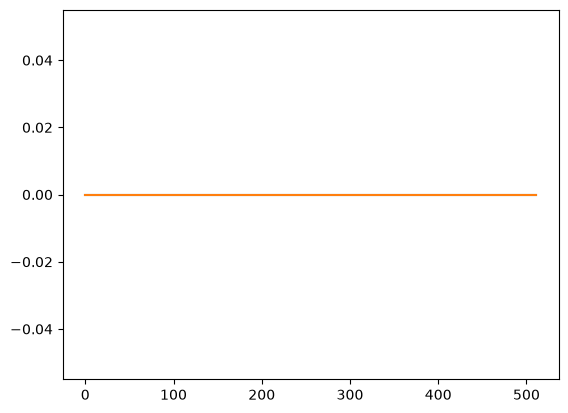

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import zhinst.utils.shfqa as shfqa

dev = "dev12247"
daq = zs.daq_server

# CW tone at 7.175 GHz out of QA0
daq.setInt(f"/{dev}/qachannels/0/mode", 0)              # spectroscopy
daq.setDouble(f"/{dev}/qachannels/0/centerfreq", 7.2e9)
daq.setDouble(f"/{dev}/qachannels/0/oscs/0/freq", 75e6)
daq.setDouble(f"/{dev}/qachannels/0/oscs/0/gain", 1.0)
daq.setInt(f"/{dev}/qachannels/0/output/on", 1)
daq.setInt(f"/{dev}/qachannels/0/input/on", 1)
daq.sync()

shfqa.configure_scope(
    daq, dev,
    input_select={0: "channel0_signal_input"},
    num_samples=4096,
    trigger_input="software_trigger0",
    num_segments=1,
    num_averages=1,
    trigger_delay=0,
)
shfqa.enable_scope(daq, dev, single=1)
daq.syncSetInt(f"/{dev}/system/swtriggers/0/single", 1)

trace, *_ = shfqa.get_scope_data(daq, dev, timeout=5)
x = np.asarray(trace[0])
print("scope nonzero:", np.count_nonzero(x), "peak:", np.max(np.abs(x)))
plt.plot(x.real[:512]); plt.plot(x.imag[:512]); plt.show()

In [17]:
dev = "dev12247"
print("scope enable :", daq.getInt(f"/{dev}/scopes/0/enable"))        # 0 = finished
print("scope single :", daq.getInt(f"/{dev}/scopes/0/single"))
print("scope length :", daq.getInt(f"/{dev}/scopes/0/length"))
print("ch0 enable   :", daq.getInt(f"/{dev}/scopes/0/channels/0/enable"))
print("ch0 select   :", daq.getInt(f"/{dev}/scopes/0/channels/0/inputselect"))
print("trigger chan :", daq.getInt(f"/{dev}/scopes/0/trigger/channel"))

scope enable : 0
scope single : 0
scope length : 4096
ch0 enable   : 1
ch0 select   : 0
trigger chan : 1024


In [18]:
shfqa.configure_scope(
    daq, dev,
    input_select={0: "channel0_rf_output"},   # <-- output, not input
    num_samples=4096,
    trigger_input="software_trigger0",
    num_segments=1, num_averages=1, trigger_delay=0,
)
shfqa.enable_scope(daq, dev, single=1)
daq.syncSetInt(f"/{dev}/system/swtriggers/0/single", 1)
trace, *_ = shfqa.get_scope_data(daq, dev, timeout=5)
x = np.asarray(trace[0])
print("output-path nonzero:", np.count_nonzero(x), "peak:", np.max(np.abs(x)))

InvalidKeywordError: Keyword 'channel0_rf_output' is not a valid option for '/dev12247/scopes/0/channels/0/inputselect'. [zi:api:16389]

In [19]:
for n in ["/system/clocks/referenceclock/in/status",
          "/system/clocks/referenceclock/in/source",
          "/system/clocks/referenceclock/in/sourceactual",
          "/system/clocks/referenceclock/in/freq"]:
    try:
        print(f"{n:52s}", daq.getDouble(f"/{dev}" + n))
    except Exception as e:
        print(f"{n:52s} <{e}>")

/system/clocks/referenceclock/in/status              0.0
/system/clocks/referenceclock/in/source              0.0
/system/clocks/referenceclock/in/sourceactual        0.0
/system/clocks/referenceclock/in/freq                100000000.0


In [20]:
import json
info = json.loads(daq.listNodesJSON(f"/{dev}/scopes/0/channels/0/inputselect"))
key = list(info.keys())[0]
opts = info[key]["Options"]
for k, v in opts.items():
    print(k, ":", v)

0 : "chan0sigin", "channel0_signal_input": Signal Input Channel 1.
48 : "sgchan0sigout", "sgchannel0_signal_output": Signal Output SG Channel 1.
49 : "sgchan1sigout", "sgchannel1_signal_output": Signal Output SG Channel 2.
50 : "sgchan2sigout", "sgchannel2_signal_output": Signal Output SG Channel 3.
51 : "sgchan3sigout", "sgchannel3_signal_output": Signal Output SG Channel 4.
52 : "sgchan4sigout", "sgchannel4_signal_output": Signal Output SG Channel 5.
53 : "sgchan5sigout", "sgchannel5_signal_output": Signal Output SG Channel 6.


In [21]:
n = f"/{dev}/scopes/0/channels/0/wave"
r = daq.get(n, flat=True)[n][0]
print(r.keys() if hasattr(r, "keys") else type(r))
v = r["vector"]
print(np.shape(v), v.dtype if hasattr(v, "dtype") else "-")
print("nonzero:", np.count_nonzero(v))
print(v[:8])

dict_keys(['timestamp', 'flags', 'vector', 'properties'])
(4096,) complex128
nonzero: 0
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [23]:
import json
for branch in ["/features/*", "/system/calib/*", "/qachannels/0/*"]:
    try:
        nodes = json.loads(daq.listNodesJSON(f"/{dev}{branch}"))
        for k in nodes:
            if "calib" in k.lower():
                print(k)
    except Exception as e:
        print(branch, "<", e, ">")

In [26]:
sg =0
import json
for k in json.loads(daq.listNodesJSON(f"/{dev}/sgchannels/{sg}/sines/0/*")):
    print(k)

/dev12247/sgchannels/0/sines/0/i/enable
/dev12247/sgchannels/0/sines/0/q/enable
/dev12247/sgchannels/0/sines/0/i/sin/amplitude
/dev12247/sgchannels/0/sines/0/i/cos/amplitude
/dev12247/sgchannels/0/sines/0/q/sin/amplitude
/dev12247/sgchannels/0/sines/0/q/cos/amplitude
/dev12247/sgchannels/0/sines/0/oscselect
/dev12247/sgchannels/0/sines/0/phaseshift
/dev12247/sgchannels/0/sines/0/harmonic
/dev12247/sgchannels/0/sines/0/freq


In [ ]:
dev = "dev12247"
sg  = 0

# RF front end for SG0
daq.setDouble(f"/{dev}/sgchannels/{sg}/centerfreq", 7.1e9)
daq.setInt(   f"/{dev}/sgchannels/{sg}/output/rflfpath", 1)
daq.setDouble(f"/{dev}/sgchannels/{sg}/output/range", 0)
daq.setInt(   f"/{dev}/sgchannels/{sg}/output/on", 1)

# CW tone from sine generator 0 at IF = 75 MHz
daq.setDouble(f"/{dev}/sgchannels/{sg}/oscs/0/freq", 75e6)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/oscselect", 0)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/harmonic", 1)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/phaseshift", 0)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/i/enable", 1)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/q/enable", 1)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/i/cos/amplitude", 1.0)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/i/sin/amplitude", 0.0)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/q/cos/amplitude", 0.0)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/q/sin/amplitude", 1.0)
daq.sync()

/dev12247/sgchannels/0/sines/0/i/enable
/dev12247/sgchannels/0/sines/0/q/enable
/dev12247/sgchannels/0/sines/0/i/sin/amplitude
/dev12247/sgchannels/0/sines/0/i/cos/amplitude
/dev12247/sgchannels/0/sines/0/q/sin/amplitude
/dev12247/sgchannels/0/sines/0/q/cos/amplitude
/dev12247/sgchannels/0/sines/0/oscselect
/dev12247/sgchannels/0/sines/0/phaseshift
/dev12247/sgchannels/0/sines/0/harmonic
/dev12247/sgchannels/0/sines/0/freq

osc freq  : 75000000.00000283
sine freq : 75000000.00000283
output on : 1
scope enable after: 0
SG-path nonzero  : 0 peak: 0.0


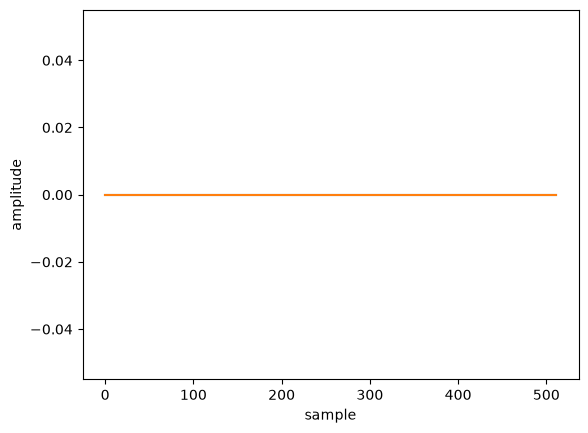

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import zhinst.utils.shfqa as shfqa

dev = "dev12247"
sg  = 0
daq = zs.daq_server

# --- SG0 RF front end ---
# daq.setDouble(f"/{dev}/sgchannels/{sg}/centerfreq", 7.2e9)
daq.setInt(   f"/{dev}/sgchannels/{sg}/output/rflfpath", 1)
daq.setDouble(f"/{dev}/sgchannels/{sg}/output/range", 0)
daq.setInt(   f"/{dev}/sgchannels/{sg}/output/on", 1)

# --- CW tone from sine generator 0 at IF = 75 MHz ---
daq.setDouble(f"/{dev}/sgchannels/{sg}/oscs/0/freq", 75e6)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/oscselect", 0)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/harmonic", 1)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/phaseshift", 0)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/i/enable", 1)
daq.setInt(   f"/{dev}/sgchannels/{sg}/sines/0/q/enable", 1)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/i/cos/amplitude", 1.0)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/i/sin/amplitude", 0.0)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/q/cos/amplitude", 0.0)
daq.setDouble(f"/{dev}/sgchannels/{sg}/sines/0/q/sin/amplitude", 1.0)
daq.sync()

print("osc freq  :", daq.getDouble(f"/{dev}/sgchannels/{sg}/oscs/0/freq"))
print("sine freq :", daq.getDouble(f"/{dev}/sgchannels/{sg}/sines/0/freq"))
print("output on :", daq.getInt(f"/{dev}/sgchannels/{sg}/output/on"))

# --- Scope on the SG digital output tap ---
shfqa.configure_scope(
    daq, dev,
    input_select={0: f"sgchannel{sg}_signal_output"},
    num_samples=4096,
    trigger_input="software_trigger0",
    num_segments=1, num_averages=1, trigger_delay=0,
)
shfqa.enable_scope(daq, dev, single=1)
daq.syncSetInt(f"/{dev}/system/swtriggers/0/single", 1)

trace, *_ = shfqa.get_scope_data(daq, dev, timeout=5)
x = np.asarray(trace[0])
print("scope enable after:", daq.getInt(f"/{dev}/scopes/0/enable"))
print("SG-path nonzero  :", np.count_nonzero(x), "peak:", np.max(np.abs(x)))

plt.plot(x.real[:512]); plt.plot(x.imag[:512])
plt.xlabel("sample"); plt.ylabel("amplitude"); plt.show()

In [30]:
print("inputselect:", daq.getInt(f"/{dev}/scopes/0/channels/0/inputselect"))
print("ch0 enable :", daq.getInt(f"/{dev}/scopes/0/channels/0/enable"))
print("trig chan  :", daq.getInt(f"/{dev}/scopes/0/trigger/channel"))
print("segments   :", daq.getInt(f"/{dev}/scopes/0/segments/enable"))
print("averaging  :", daq.getInt(f"/{dev}/scopes/0/averaging/enable"))
print("time       :", daq.getInt(f"/{dev}/scopes/0/time"))

inputselect: 0
ch0 enable : 1
trig chan  : 1024
segments   : 0
averaging  : 0
time       : 0
